# TAS Diagram

The TAS diagram (Total Alkali-Silica diagram; Le Maitre et al., 1989) classifies volcanic rocks using:

- `SiO2` on the x-axis;
- `Na2O + K2O` on the y-axis.

This notebook shows two ways to work with TAS diagrams in `geochem`:

1. the high-level `TAS()` function for quick plots;
2. lower-level building blocks for customized figures.

## Import Libraries and Load the Dataset

The plotting tools are available from `geochem.plt`. The example dataset is loaded and preprocessed before plotting.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geochem.plt as gc

In [2]:
DOCS_DIR = Path.cwd()
if not (DOCS_DIR / "data_example.csv").exists():
    DOCS_DIR = Path.cwd() / "docs"

csv_file = DOCS_DIR / "data_example.csv"
df = pd.read_csv(csv_file)

gc.preproc(df)
df.head()

Strip whitespaces from column names
>  column names before:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2 ', 'Al2O3 ', 'TiO2 ', 'FeO', 'Fe2O3 ', 'FeOT', 'CaO ', 'MgO', 'MnO ', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']
>  column names after:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2', 'Al2O3', 'TiO2', 'FeO', 'Fe2O3', 'FeOT', 'CaO', 'MgO', 'MnO', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']

Ensuring geochemical data columns are numeric
>  Processed/verified numeric columns: Cr (parsed)

Check columns with Fe oxides and calculate FeOT
.. FeO column in database
.. Fe2

,Sample,Type,Description,Reference,Source,SiO2,Al2O3,TiO2,FeO,Fe2O3,...,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu
0,HOR-06-01,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.55,17.42,0.81,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLHE1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.35,17.76,0.83,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLHE2,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.08,17.02,0.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CLHE-TF-04,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,51.51,13.99,0.64,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLHW1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.73,17.91,0.88,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Draw an Empty TAS Diagram

Calling `TAS()` without data draws the diagram only. This is useful for inspecting the classification fields.

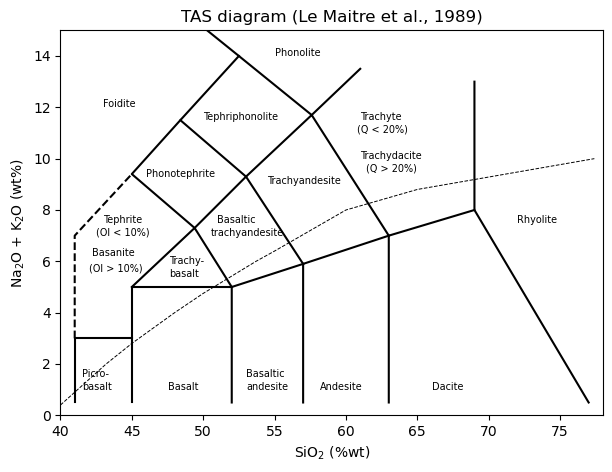

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
gc.TAS(fmt={"show": False}, ax=ax)
plt.show()

The `abbrev` formatting option switches field labels to abbreviations.

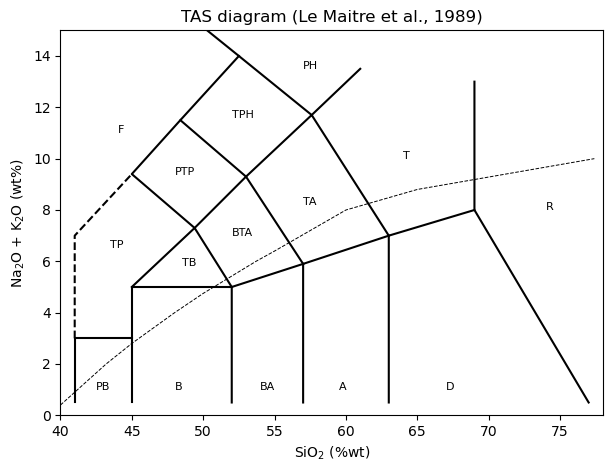

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
gc.TAS(fmt={"abbrev": True, "show": False}, ax=ax)
plt.show()

## High-Level Plot from a DataFrame

The high-level `TAS()` function can take a preprocessed DataFrame directly. By default, major oxides are normalized to 100 wt% before plotting.

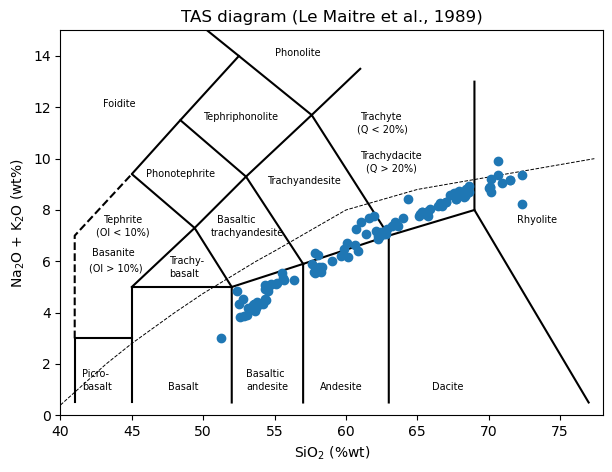

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
gc.TAS(df, fmt={"show": False}, ax=ax)
plt.show()

The `groupby` formatting option uses a metadata column to plot groups with different colors.

In [6]:
df["Source"].unique()

<StringArray>
['Hornitos', 'Manantial Pelado', 'Mondaca', 'Quizapu']
Length: 4, dtype: str

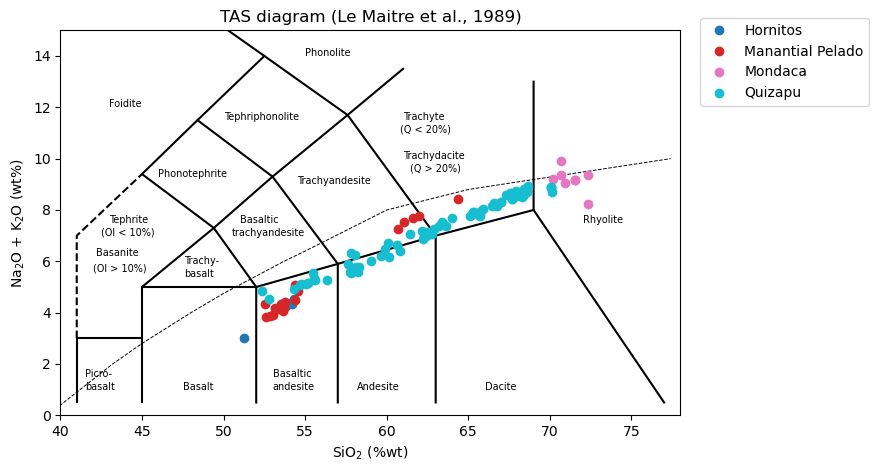

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
gc.TAS(df, fmt={"groupby": "Source", "show": False}, ax=ax)
plt.show()

You can also filter the DataFrame before plotting.

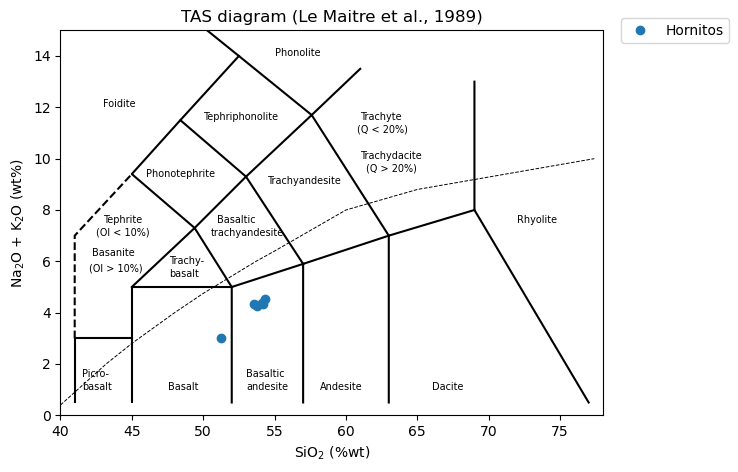

In [8]:
df_hornitos = df[df["Source"] == "Hornitos"]

fig, ax = plt.subplots(figsize=(7, 5))
gc.TAS(df_hornitos, fmt={"groupby": "Source", "show": False}, ax=ax)
plt.show()

## NumPy-Style Input

`TAS()` also accepts a sequence with two arrays: `[SiO2, Na2O + K2O]`. This is useful when data have already been processed outside a DataFrame.

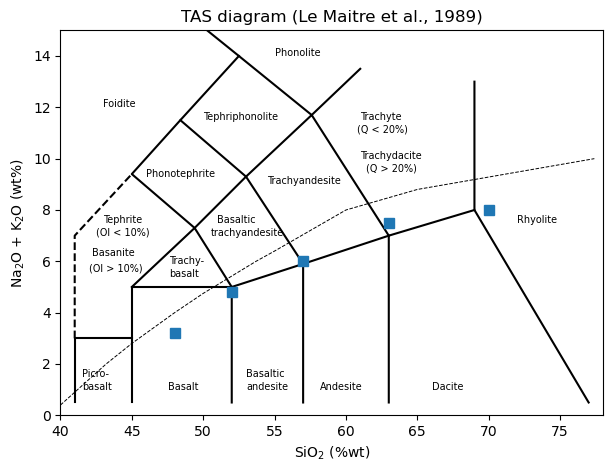

In [9]:
sio2 = np.array([48.0, 52.0, 57.0, 63.0, 70.0])
alkalis = np.array([3.2, 4.8, 6.0, 7.5, 8.0])

fig, ax = plt.subplots(figsize=(7, 5))
gc.TAS([sio2, alkalis], fmt={"marker": "s", "ms": 7, "show": False}, ax=ax)
plt.show()

## Build a TAS Figure Step by Step

For custom figures, use the lower-level `tas_diagram()` function to draw the background, then add data with Matplotlib.

The manual workflow is:

1. select major oxides;
2. apply closure normalization;
3. calculate total alkalis;
4. draw the TAS diagram;
5. add the data with Matplotlib.

In [10]:
major_oxides = gc.getnames_major()
major_oxides

['SiO2', 'Al2O3', 'TiO2', 'FeOT', 'CaO', 'MgO', 'MnO', 'Na2O', 'K2O', 'P2O5']

In [11]:
df_major = df[major_oxides].copy()
df_major = gc.closure(df_major, total=100)
df_major["alkalis"] = df_major["Na2O"] + df_major["K2O"]
df_major["Source"] = df["Source"]
df_major = df_major.dropna(subset=["SiO2", "alkalis"])

df_major.head()

,SiO2,Al2O3,TiO2,FeOT,CaO,MgO,MnO,Na2O,K2O,P2O5,alkalis,Source
0,54.167510,17.620878,0.819340,7.566255,9.569088,5.614000,0.141614,3.338054,0.991301,0.171960,4.329355,Hornitos
1,54.144252,17.692767,0.826858,7.531381,9.663280,5.469217,0.139470,3.367205,0.996214,0.169356,4.363419,Hornitos
2,53.794887,16.930270,0.785835,7.629563,9.400179,6.883517,0.139262,3.282602,0.984781,0.169104,4.267383,Hornitos
3,51.258832,13.921783,0.636879,8.090357,9.214847,13.593392,0.149269,2.368395,0.646831,0.119415,3.015225,Hornitos
4,53.542601,17.847534,0.876931,7.483807,9.546587,6.038864,0.139512,3.368211,0.976582,0.179372,4.344793,Hornitos


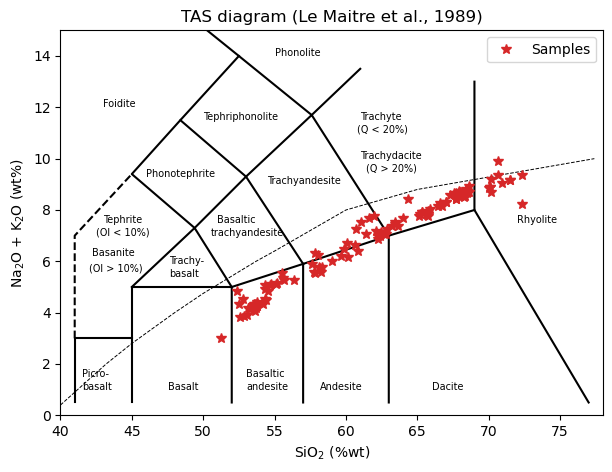

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
gc.tas_diagram(fmt={"show": False}, ax=ax)

ax.plot(
    df_major["SiO2"],
    df_major["alkalis"],
    marker="*",
    linestyle="",
    ms=7,
    color="tab:red",
    label="Samples",
)

ax.legend()
plt.show()

## Custom Grouped Figure with Matplotlib

The same low-level approach can be customized by plotting each group separately.

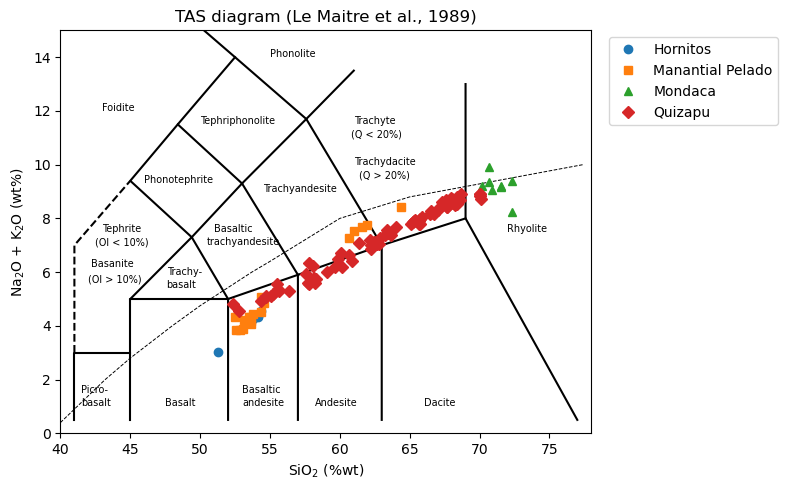

In [13]:
markers = {
    "Hornitos": "o",
    "Manantial Pelado": "s",
    "Mondaca": "^",
    "Quizapu": "D",
}

fig, ax = plt.subplots(figsize=(8, 5))
gc.tas_diagram(fmt={"show": False}, ax=ax)

for source, group in df_major.groupby("Source"):
    ax.plot(
        group["SiO2"],
        group["alkalis"],
        marker=markers.get(source, "o"),
        linestyle="",
        ms=6,
        label=source,
    )

ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
fig.tight_layout()
plt.show()

## Summary

Use `gc.TAS(df)` for quick TAS diagrams. Use `gc.tas_diagram(ax=ax)` plus Matplotlib commands when you need full control over symbols, colors, labels, and figure layout.